# RSI-Divergence — a quantitative teardown 🔬
### Confirmed swing-low pairing · Welch/HAC splits · a 20-seed random-signal placebo · the retail-era contrast · a cost-timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_random_signal%3F: Busted](https://img.shields.io/badge/Beats_a_random_signal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a lower price low with a higher RSI(14) low marks a reversal** — is a textbook pattern with no stated economic mechanism beyond crowd psychology. The job here is to detect it algorithmically (never by eye), measure it honestly, and ask the only question that pays: *does it beat the basket's own drift?*

> ⚠️ **Data note.** Daily OHLC, SPY + QQQ/IWM/AAPL/MSFT/NVDA, 2010-01-04 → 2026-06-30, yfinance, cached. No hardcoded calendar — the pattern is purely algorithmic. No survivorship (index ETFs + still-listed mega-caps), though the basket does skew bullish (named explicitly below). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `249b0ef2b1da`, `dd77b24463c4`, `3d13a729a6a7`, `1d9e6ffa4dab`, `db3a2e6ab5ea`, `4f4ce66b8f52`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rsi_divergence import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TAPE = data.load_real()
    EVENTS = st.basket_events(TAPE)
else:
    TAPE = EVENTS = None
print("real cache present:", HAVE_REAL, "| tickers:",
      0 if TAPE is None else len(TAPE), "| confirmed divergences:",
      0 if EVENTS is None else len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'n_events': 109, 'by_ticker': {'AAPL': 16, 'IWM': 16, 'MSFT': 22, 'NVDA': 22, 'QQQ': 15, 'SPY': 18}, 'n_base': 24743, 'headline': {5: (1.89, 31.6, -29.71, -0.62, -0.63, 109, 52.3, 43.0, 61.4), 10: (57.58, 68.83, -11.25, -0.2, -0.2, 109, 56.0, 46.6, 64.9), 20: (84.08, 145.26, -61.17, -0.84, -0.82, 109, 56.9, 47.5, 65.8)}, 'placebo': {5: (1.89, 32.19, 36.12, 0.799), 10: (57.58, 71.01, 50.38, 0.613), 20: (84.08, 150.53, 71.43, 0.827)}, 'era_split': '2019-10-01', 'era_early': 20.16, 'era_early_n': 68, 'era_late': 119.64, 'era_late_n': 41, 'era_diff_t': 0.83, 'tw_gross': 57.58, 'tw_net5': 47.58, 'tw_net10': 37.58, 'tw_n': 109, 'tw_hit': 56.0, 'tw_hit_lo': 46.6, 'tw_hit_hi': 64.9, 'tw_worst': -1434.8, 'tw_best': 1809.2, 'uncond_hit10': 59.7, 'uncond_n10': 24822, 'syn_null_mean': 0.31, 'syn_null_sd': 1.08, 'syn_null_fire': 0, 'syn_planted_t': 6.96, 'syn_planted_nw': 7.09, 'syn_planted_n': 102, 'syn_planted_mean': 179.3, 'fp': {'SPY': '249b0ef2b1da', 'QQQ': 'dd77b24463c4', 'IWM': '3d13a729a6a7', 'AAPL': '1d9e6ffa4dab', 'MSFT': 'db3a2e6ab5ea', 'NVDA': '4f4ce66b8f52'}}


real cache present: True | tickers: 6 | confirmed divergences: 109


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | gap vs unconditional **-11.2 bps** (10d), Welch **t = -0.20**, NW **t = -0.20**; random-signal placebo beats it on **61%** of draws |
| **Tradability** | `MIRAGE` | net +47.6 bps/trade at 5 bps cost, but gross is already at/below the unconditional bar; worst trade -1435 bps |
| **Beats a random signal?** | `BUSTED` | p(random ≥ observed) = 0.80 / 0.61 / 0.83 at 5/10/20d — random wins the majority of the time at every horizon |

> 💡 In plain words: the pattern is not a weak edge fighting costs — it never clears the starting line.

## 1 · The claim, steelmanned

Let $D_t \in \{0,1\}$ flag a **confirmed** bullish divergence: a swing low at $t$ with price $P_t < P_{t'}$ and RSI$_t$ > RSI$_{t'}$ vs the previous confirmed swing low $t'$. A swing low is only knowable `order`=5 bars after it prints (the definition itself requires future bars — not a look-ahead violation any more than RSI(14) needing 14 days of history). The claims:

- **H₁ (signal).** $E[r_{t+1:t+h} \mid D_t=1] > E[r_{t+1:t+h}]$ (unconditional) for $h \in \{5,10,20\}$.
- **H₂ (beats random).** The divergence signal beats a random signal of the same count, same tickers.
- **H₃ (bankable).** Net of costs, long-only, the pattern pays.

We find **H₁ rejected** (negative gap at all three horizons), **H₂ rejected** (random beats real 61-83% of the time) and **H₃ moot** — there's no gross edge to protect from costs.

## 2 · So what? — inference design

Signal-vs-unconditional uses a **Welch t** on the group split. Because h-day forward-return windows overlap (two divergences within h days of each other on the same or different tickers share tape), we cross-check with a pooled **Newey-West (HAC, lag=h)** dummy regression. The hit rate carries a **Wilson interval**. The random-signal placebo draws the observed signal COUNT per ticker from random eligible dates, **20 seeds × 200 draws**, and reports a right-tail p-value (share of random draws whose mean ≥ the observed divergence mean — the claim predicts a positive edge, so a high p means random usually does *better*).

## 3 · How we'd know — the protocol

- **Universe.** SPY + QQQ/IWM/AAPL/MSFT/NVDA, 2010-01-04 → 2026-06-30, daily OHLC (yfinance). No survivorship (index ETFs + still-listed mega-caps).
- **Pattern.** Confirmed 11-bar-fractal swing lows (`order=5`); bullish divergence = lower price low, higher RSI(14) low vs the previous confirmed swing.
- **Events.** 109 confirmed divergences across 6 tickers (AAPL 16, IWM 16, MSFT 22, NVDA 22, QQQ 15, SPY 18).
- **Execution (single documented lag).** Enter next session's open after confirmation (zero look-ahead), exit at the close h sessions later.
- **Comparisons.** (a) unconditional forward-return distribution, same formula, every day; (b) random-signal placebo, matched count, 20 seeds × 200 draws.
- **Cross-check.** Newey-West (lag=h) on the pooled dummy regression.
- **Sub-period.** Split 2019-10-01 (zero-commission retail era), tested as a *difference*, not eyeballed.
- **Third axis.** Long-only cost-timer, 2 × one-way × NAV, 5/10 bps.
- **Control.** Synthetic random walk, planted bounce injected on the pipeline's own flagged dates; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split, three horizons

Welch t on the divergence-vs-unconditional gap, with the NW(lag=h) cross-check for the overlap in forward-return windows.

h= 5d: signal   +1.89 bps (n=109)  vs unconditional  +31.60 bps (n=24,743)  gap  -29.71 bps  Welch t=-0.62  NW t=-0.63  hit 52.3%
h=10d: signal  +57.58 bps (n=109)  vs unconditional  +68.83 bps (n=24,713)  gap  -11.25 bps  Welch t=-0.20  NW t=-0.20  hit 56.0%
h=20d: signal  +84.08 bps (n=109)  vs unconditional +145.26 bps (n=24,653)  gap  -61.17 bps  Welch t=-0.84  NW t=-0.82  hit 56.9%


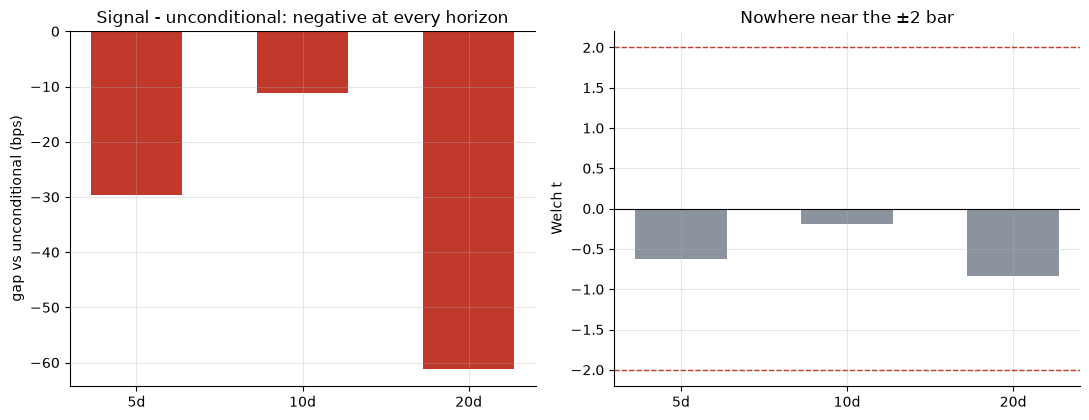

In [2]:
if HAVE_REAL:
    hs = {h: st.headline_stats(TAPE, EVENTS, h) for h in (5, 10, 20)}
    for h in (5, 10, 20):
        s = hs[h]
        print(f"h={h:>2d}d: signal {s['sig_mean_bps']:+7.2f} bps (n={s['n_sig']})  "
              f"vs unconditional {s['base_mean_bps']:+7.2f} bps (n={s['n_base']:,})  "
              f"gap {s['gap_bps']:+7.2f} bps  Welch t={s['welch_t']:+.2f}  "
              f"NW t={s['nw_t']:+.2f}  hit {s['hit_rate']*100:.1f}%")
    gaps = [hs[h]['gap_bps'] for h in (5, 10, 20)]
    ts = [hs[h]['welch_t'] for h in (5, 10, 20)]
else:
    gaps = [R['headline'][h][2] for h in (5, 10, 20)]
    ts = [R['headline'][h][3] for h in (5, 10, 20)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['5d', '10d', '20d'], gaps, color=RED, width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('gap vs unconditional (bps)')
a1.set_title('Signal - unconditional: negative at every horizon')
a2.bar(['5d', '10d', '20d'], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.55)
a2.axhline(0, c='k', lw=.8)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('Welch t'); a2.set_title('Nowhere near the ±2 bar')
plt.tight_layout(); plt.show()

> 💡 In plain words: the gap is negative at 5d (-29.7 bps), 10d (-11.2 bps) and 20d (-61.2 bps) — the divergence signal is a laggard against the same basket's ordinary day, and no *t* gets within 1.2 of the ±2 bar in either direction.

### 4b · The random-signal placebo — the fairest bar

20 seeds × 200 draws of the exact signal count per ticker, from random eligible dates: p = share of random draws with mean ≥ the observed divergence mean.

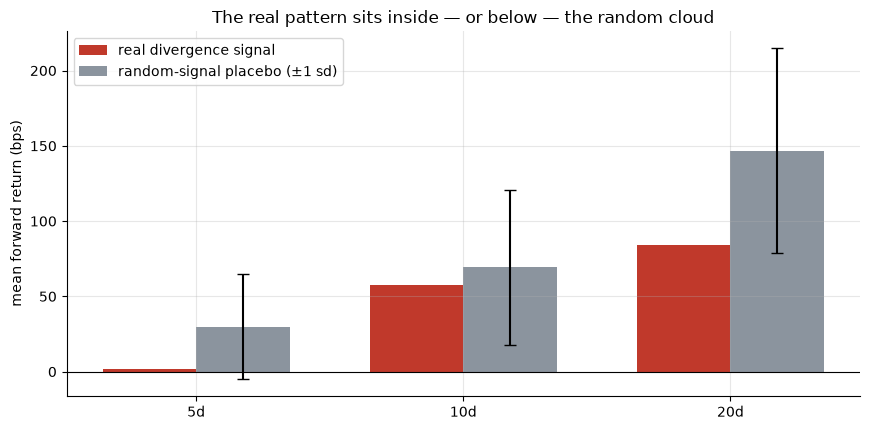

canonical p-values (results.md): {5: 0.799, 10: 0.613, 20: 0.827}


In [3]:
if HAVE_REAL:
    pl = {h: st.random_signal_placebo(TAPE, EVENTS, h, n_draws_per_seed=100, n_seeds=6)
          for h in (5, 10, 20)}
    obs = [pl[h]['obs']*1e4 for h in (5, 10, 20)]
    pm = [pl[h]['placebo_mean']*1e4 for h in (5, 10, 20)]
    ps = [pl[h]['placebo_sd']*1e4 for h in (5, 10, 20)]
else:
    obs = [R['placebo'][h][0] for h in (5, 10, 20)]
    pm = [R['placebo'][h][1] for h in (5, 10, 20)]
    ps = [R['placebo'][h][2] for h in (5, 10, 20)]
x = np.arange(3); w = .35
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x - w/2, obs, w, color=RED, label='real divergence signal')
ax.bar(x + w/2, pm, w, yerr=ps, color=GREY, capsize=4, label='random-signal placebo (±1 sd)')
ax.set_xticks(x); ax.set_xticklabels(['5d','10d','20d'])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean forward return (bps)')
ax.set_title('The real pattern sits inside — or below — the random cloud')
ax.legend(); plt.tight_layout(); plt.show()
print('canonical p-values (results.md):',
      {h: R['placebo'][h][3] for h in (5, 10, 20)})

> 💡 In plain words: the canonical (20-seed × 200-draw) p-values are **0.799 / 0.613 / 0.827** at 5/10/20 days — a random signal beats the real pattern on the clear majority of draws at every horizon. This is the single most decisive number in the study: it isn't that the divergence signal is *weak*, it's that doing nothing in particular (same tickers, same count, random timing) usually wins.

### 4c · Era contrast — pre vs post the zero-commission retail era

Split at **2019-10-01** (Schwab/Robinhood cut equity commissions to zero — retail chart-pattern trading, of which RSI divergence is a textbook example, went frictionless and crowded), tested as a difference, not eyeballed.

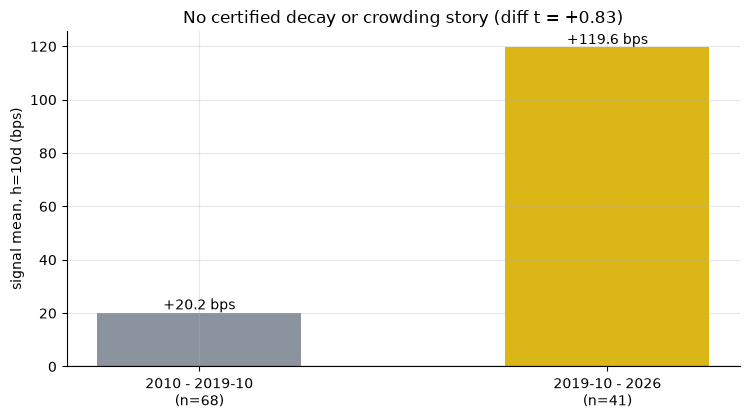

early +20.2 bps (n=68)  late +119.6 bps (n=41)  diff t = +0.83


In [4]:
if HAVE_REAL:
    ec = st.era_contrast(TAPE, EVENTS, 10, R['era_split'])
    e, l, n_e, n_l, dt = (ec['early_bps'], ec['late_bps'], ec['n_early'],
                          ec['n_late'], ec['welch_t_diff'])
else:
    e, l, n_e, n_l, dt = (R['era_early'], R['era_late'], R['era_early_n'],
                          R['era_late_n'], R['era_diff_t'])
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar([f'2010 - 2019-10\n(n={n_e})', f'2019-10 - 2026\n(n={n_l})'], [e, l],
       color=[GREY, AMBER], width=.5)
for i,v in enumerate([e, l]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('signal mean, h=10d (bps)')
ax.set_title(f'No certified decay or crowding story (diff t = {dt:+.2f})')
plt.tight_layout(); plt.show()
print(f'early {e:+.1f} bps (n={n_e})  late {l:+.1f} bps (n={n_l})  diff t = {dt:+.2f}')

> 💡 In plain words: the point estimate is larger post-2019 (+20.2 → +119.6 bps), but the difference is **not certified** (t = +0.83) — with only 68 and 41 events per era there's no basis to claim decay or a crowding effect. Both eras are already statistically indistinguishable from noise on their own.

### 4d · The third axis — a timer with costs

Long-only (this is a bullish pattern), enter next open, exit at the close 10 sessions later, 2 × one-way costs per round trip.

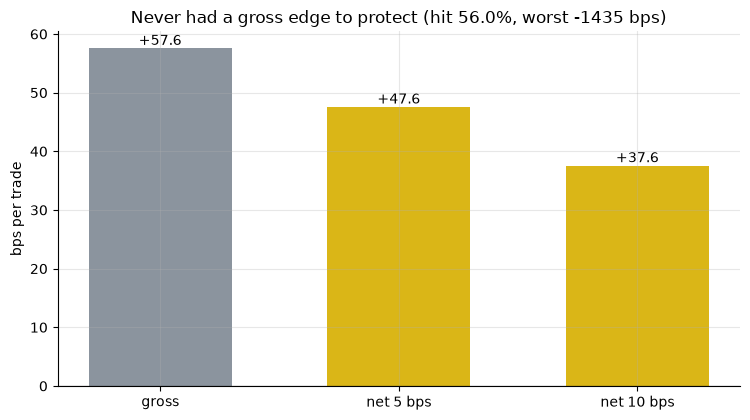

gross +57.6 -> net +47.6 / +37.6 bps;  hit 56.0%;  worst -1434.8 bps;  best +1809.2 bps


In [5]:
if HAVE_REAL:
    rows = {cb: st.timer_with_costs(TAPE, EVENTS, 10, cost_bps=cb) for cb in (5.0, 10.0)}
    g = rows[5.0]['gross_bps']; n5, n10 = rows[5.0]['net_bps'], rows[10.0]['net_bps']
    hit, worst, best = rows[5.0]['hit_rate']*100, rows[5.0]['worst_bps'], rows[5.0]['best_bps']
else:
    g, n5, n10 = R['tw_gross'], R['tw_net5'], R['tw_net10']
    hit, worst, best = R['tw_hit'], R['tw_worst'], R['tw_best']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['gross', 'net 5 bps', 'net 10 bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('bps per trade')
ax.set_title(f'Never had a gross edge to protect (hit {hit:.1f}%, worst {worst:.0f} bps)')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f} -> net {n5:+.1f} / {n10:+.1f} bps;  hit {hit:.1f}%;  '
      f'worst {worst:+.1f} bps;  best {best:+.1f} bps')

> 💡 In plain words: gross **+57.6 bps/trade** is already at or below the unconditional bar (59.7% hit rate vs 56.0% for the signal); 5-10 bps of cost turns a marginal gross number into +47.6 / +37.6 bps net — and the worst single trade (-1435 bps) is larger in magnitude than 25 average wins stacked together. There was never a gross edge to protect.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic random walk with engineered periodic dips (so genuine swing lows recur); a TUNABLE bounce is planted exactly on the dates the study's **own detector** flags — never a hand-tuned proxy. The null (bounce=0) is checked over **20 seeds**.

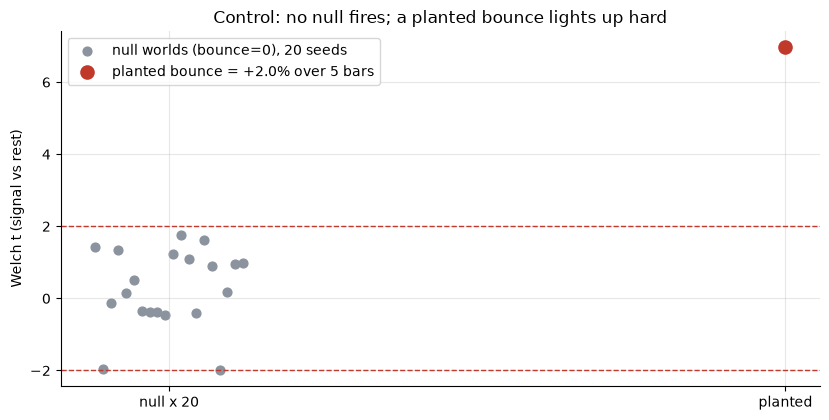

null: mean t = +0.31 (sd 1.08), |t|>=2 in 0/20 seeds  |  planted t = +6.96


In [6]:
null_ts = []
for s_ in range(20):
    world = data.synthetic_world(bounce=0.0, seed=669 + s_)
    null_ts.append(st.synthetic_detect(world, h=10)['welch_t'])
null_ts = np.asarray(null_ts)
world = data.synthetic_world(bounce=0.02, seed=669)
planted = st.synthetic_detect(world, h=10)
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (bounce=0), 20 seeds')
ax.scatter([1], [planted['welch_t']], color=RED, s=90, zorder=5,
           label='planted bounce = +2.0% over 5 bars')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (signal vs rest)')
ax.set_title('Control: no null fires; a planted bounce lights up hard')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = '
      f"{planted['welch_t']:+.2f}")

> 💡 In plain words: across 20 null worlds the detector averages t = +0.31 (sd 1.08) and **never** crosses the bar; planting a 2% bounce exactly where the detector's own pipeline flags a signal reads t = 6.96 (NW t = 7.09). The machinery is unbiased and has power — the real-tape null result is the genuine article, not a blind spot. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — gap vs unconditional negative at every horizon (-29.7 / -11.2 / -61.2 bps at 5/10/20d), Welch t -0.62 / -0.20 / -0.84 (NW cross-check matches); a random signal of the same size beats the real pattern on 80% / 61% / 83% of draws.
- **Tradability `MIRAGE`** — no gross edge survives contact with the unconditional bar; costs only make a losing proposition worse; worst single trade -1435 bps.
- **"Beats a random signal?" `BUSTED`** — the fairest control on this desk outperforms the textbook pattern at every horizon tested. The visual cleanliness of a divergence on a chart does not survive algorithmic, non-cherry-picked detection.

## 6 · Going further

- **Why the visual pattern feels so much stronger than the data.** Chart-reading involves choosing *which* two swing lows to connect after you've already seen what happened next — the algorithmic detector has no such freedom, and the edge evaporates with the hindsight.
- **The general lesson.** Divergence claims recur across the technical-analysis canon (price/volume, price/RSI, price/MACD…) — the shared structure (two confirmed extrema disagreeing in direction) is worth testing systematically rather than indicator-by-indicator; this desk's [109-obv-divergence](../../109-obv-divergence/) does the volume version and finds the same nothing.
- **Dedup map:** [109-obv-divergence](../../109-obv-divergence/) (volume divergence), [75-knee-jerk](../../75-knee-jerk/) (RSI(2) mean reversion, no divergence), [301-triple-rsi](../../301-triple-rsi/) (multi-timeframe RSI alignment), [428-stochastic-rsi](../../428-stochastic-rsi/) (Stochastic-on-RSI timer), [178-cci](../../178-cci/) (a different oscillator's breach rule) — none test the confirmed-swing-low pairing this study does.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*